In [8]:
%matplotlib inline

import collections
import re
from pathlib import Path

from d2l import torch as d2l

In [9]:
data_path = Path(
    "/home/anna/projects/maverick/src/ch09_recurrent_neural_networks/data/timemachine.txt"
)

raw_text = data_path.read_text(
    encoding="utf-8",
)

text = re.sub(
    "[^A-Za-z]+",
    " ",
    raw_text,
).lower()

text[:60]

'the time machine by h g wells i the time traveller for so it'

In [10]:
class Vocab:
    """Vocabulary for text."""

    def __init__(
        self,
        tokens=[],
        min_freq=0,
        reserved_tokens=[],
    ):
        if tokens and isinstance(tokens[0], list):
            tokens = [
                token
                for line in tokens
                for token in line
            ]

        counter = collections.Counter(tokens)

        self.token_freqs = sorted(
            counter.items(),
            key=lambda item: item[1],
            reverse=True,
        )

        self.idx_to_token = list(
            sorted(
                set(
                    ["<unk>"]
                    + reserved_tokens
                    + [
                        token
                        for token, freq in self.token_freqs
                        if freq >= min_freq
                    ]
                )
            )
        )

        self.token_to_idx = {
            token: index
            for index, token in enumerate(self.idx_to_token)
        }

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(
                tokens,
                self.unk,
            )

        return [
            self.__getitem__(token)
            for token in tokens
        ]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [
                self.idx_to_token[int(index)]
                for index in indices
            ]

        return self.idx_to_token[indices]

    @property
    def unk(self):
        return self.token_to_idx["<unk>"]

In [13]:
words = text.split()

word_vocab = Vocab(words)

word_vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

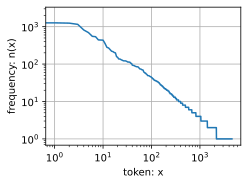

In [14]:
freqs = [
    freq
    for token, freq in word_vocab.token_freqs
]

d2l.plot(
    freqs,
    xlabel="token: x",
    ylabel="frequency: n(x)",
    xscale="log",
    yscale="log",
)

In [15]:
bigram_tokens = [
    "--".join(pair)
    for pair in zip(
        words[:-1],
        words[1:],
    )
]

bigram_vocab = Vocab(bigram_tokens)

bigram_vocab.token_freqs[:10]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73)]

In [16]:
trigram_tokens = [
    "--".join(triple)
    for triple in zip(
        words[:-2],
        words[1:-1],
        words[2:],
    )
]

trigram_vocab = Vocab(trigram_tokens)

trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

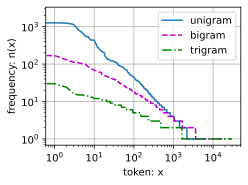

In [17]:
bigram_freqs = [
    freq
    for token, freq in bigram_vocab.token_freqs
]

trigram_freqs = [
    freq
    for token, freq in trigram_vocab.token_freqs
]

d2l.plot(
    [
        freqs,
        bigram_freqs,
        trigram_freqs,
    ],
    xlabel="token: x",
    ylabel="frequency: n(x)",
    xscale="log",
    yscale="log",
    legend=[
        "unigram",
        "bigram",
        "trigram",
    ],
)